# StyleJourney VAE vs REPA-E sdvae — Side-by-Side Comparison

Goal: compare the baked-in VAE from the StyleJourney SD1.5 checkpoint with the
REPA-E end-to-end trained VAE (REPA-E/sdvae on HuggingFace).

Method:
1. Load StyleJourney UNet + VAE (baked-in)
2. Load REPA-E sdvae (drop-in replacement)
3. Generate images with CLIP conditioning through the same UNet
4. Decode the same latents with both VAEs and compare side-by-side

This isolates the VAE decode quality — the UNet, text encoder, scheduler, seed,
and noisy latents are identical for each pair.


## Section 0: Google Drive Mount

In [1]:
# @title 0.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_OUT = '/content/drive/MyDrive/gemma3-sd'
os.makedirs(DRIVE_OUT, exist_ok=True)
print(f"Artifacts will be saved to: {DRIVE_OUT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts will be saved to: /content/drive/MyDrive/gemma3-sd


## Section 1: Environment Setup

In [2]:
# @title 1.1 Install dependencies
!pip install -q -U --upgrade-strategy only-if-needed \
  "Pillow==11.3.0" \
  "accelerate==1.6.0" \
  "transformers==4.54.1" \
  "diffusers[torch]==0.32.1" \
  "safetensors==0.4.5" \
  "matplotlib" \
  "tqdm"

print("Dependencies installed")


Dependencies installed


In [3]:
# @title 1.2 Import check
import torch, numpy as np, PIL
import transformers, diffusers

print("OK")
print("Torch:", torch.__version__, "CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("NumPy:", np.__version__)
print("Pillow:", PIL.__version__)
print("Transformers:", transformers.__version__)
print("Diffusers:", diffusers.__version__)


OK
Torch: 2.10.0+cu128 CUDA: 12.8
GPU: Tesla T4
NumPy: 2.0.2
Pillow: 11.3.0
Transformers: 4.54.1
Diffusers: 0.32.1


In [4]:
# @title 1.3 HuggingFace Login via Colab Secrets
from google.colab import userdata
import os
hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Missing HF_TOKEN in Colab secrets. Add it via the key icon in the sidebar.")
os.environ["HF_TOKEN"] = hf_token
print("HF_TOKEN loaded from Colab secrets.")


HF_TOKEN loaded from Colab secrets.


## Section 2: Load StyleJourney SD1.5 (UNet + baked-in VAE + Scheduler)

In [5]:
# @title 2.1 Load CLIP text encoder (standard SD1.5 conditioning)
from transformers import CLIPTextModel, CLIPTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLIP_ID = "openai/clip-vit-large-patch14"
print(f"Loading CLIP: {CLIP_ID}")
clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_ID)
clip_model = CLIPTextModel.from_pretrained(
    CLIP_ID,
    torch_dtype=torch.float16,
).to(device).eval()
for p in clip_model.parameters():
    p.requires_grad = False
print(f"  CLIP hidden size: {clip_model.config.hidden_size}")
print("  CLIP frozen.")


Loading CLIP: openai/clip-vit-large-patch14


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

  CLIP hidden size: 768
  CLIP frozen.


In [6]:
# @title 2.2 Load StyleJourney UNet + VAE + Scheduler from safetensors
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, AutoencoderKL, DDPMScheduler
import gc

SD_CHECKPOINT_CANDIDATES = [
    "/content/drive/MyDrive/model/stylejourney_v10.safetensors",
    "/models/stylejourney_v10.safetensors",
]

def resolve_sd_checkpoint():
    for path in SD_CHECKPOINT_CANDIDATES:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        "stylejourney_v10.safetensors not found. Upload/copy it to one of: "
        + ", ".join(SD_CHECKPOINT_CANDIDATES)
    )

SD_CHECKPOINT = resolve_sd_checkpoint()
print(f"Loading StyleJourney checkpoint from: {SD_CHECKPOINT}")

pipe = StableDiffusionPipeline.from_single_file(
    SD_CHECKPOINT,
    torch_dtype=torch.float32,
    safety_checker=None,
    requires_safety_checker=False,
)
unet = pipe.unet.to(device)
stylejourney_vae = pipe.vae.to(device).eval()
train_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

# Drop unused parts
pipe.text_encoder = None
pipe.tokenizer = None
pipe.safety_checker = None
del pipe
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

unet_dtype = next(unet.parameters()).dtype
print(f"  UNet cross_attention_dim: {unet.config.cross_attention_dim}")
print(f"  UNet dtype: {unet_dtype}")
print(f"  StyleJourney VAE dtype: {next(stylejourney_vae.parameters()).dtype}")
print(f"  StyleJourney VAE latent channels: {stylejourney_vae.config.latent_channels}")
print("  Loaded ✓")


Loading StyleJourney checkpoint from: /content/drive/MyDrive/model/stylejourney_v10.safetensors


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
In this conversion only the non-EMA weights are extracted. If you want to instead extract the EMA weights (usually better for inference), please make sure to add the `--extract_ema` flag.


  UNet cross_attention_dim: 768
  UNet dtype: torch.float32
  StyleJourney VAE dtype: torch.float32
  StyleJourney VAE latent channels: 4
  Loaded ✓


## Section 3: Load REPA-E VAE (drop-in replacement)

REPA-E/sdvae is an end-to-end trained VAE that serves as a drop-in replacement for
the standard SD-VAE. It uses the same latent shape (4×64×64 for 512×512 images)
but was jointly optimized with the diffusion model via representation-alignment loss.

Paper: https://arxiv.org/abs/2504.10483
Model: https://huggingface.co/REPA-E/sdvae


In [7]:
# @title 3.1 Load REPA-E VAE
# The REPA-E VAE uses the same architecture as SD-VAE (AutoencoderKL with
# ch_mult=[1,2,4,4], embed_dim=4) but was end-to-end trained with the
# diffusion model. It uses per-channel batch-norm latent normalization
# instead of SD-VAE's 0.18215 scaling factor.
#
# Loading approach: clone REPA-E repo, instantiate VAE, load weights,
# also load latent stats for denormalization before decode.

!git clone --depth 1 https://github.com/End2End-Diffusion/REPA-E.git /content/REPA-E 2>/dev/null || true
!pip install -q dictdot  # REPA-E dependency for dictdot wrapper
import sys
if "/content/REPA-E" not in sys.path:
    sys.path.insert(0, "/content/REPA-E")

from huggingface_hub import hf_hub_download
from models.autoencoder import vae_models  # REPA-E VAE factory
import torch.nn as nn

# Download checkpoints
repa_vae_path = hf_hub_download("REPA-E/sdvae", "sdvae-f8d4.pt")
repa_stats_path = hf_hub_download("REPA-E/sdvae", "sdvae-f8d4-latents-stats.pt")
print(f"REPA-E VAE checkpoint: {repa_vae_path}")
print(f"REPA-E latent stats: {repa_stats_path}")

# Instantiate the VAE with f8d4 config (same as SD1.5: 4 latent channels, 8x downsampling)
repa_vae = vae_models["f8d4"]().to(device)
repa_vae.load_state_dict(torch.load(repa_vae_path, map_location="cpu"))
repa_vae.eval()
for p in repa_vae.parameters():
    p.requires_grad = False

# Load latent normalization stats (used by REPA-E's diffusion model)
latent_stats = torch.load(repa_stats_path, map_location="cpu")
repa_latents_scale = latent_stats["latents_scale"].to(device)  # 1/sqrt(var)
repa_latents_bias = latent_stats["latents_bias"].to(device)    # mean
print(f"REPA-E latent scale: {repa_latents_scale.squeeze().tolist()}")
print(f"REPA-E latent bias: {repa_latents_bias.squeeze().tolist()}")

# Attach a compatible config for the decode helper
class VAEConfig:
    scaling_factor = 1.0  # REPA-E uses batch-norm, not SD scaling
repa_vae.config = VAEConfig()

# Adapt the VAE's decode/encode to match diffusers API expectations.
# REPA-E VAE.decode(z) returns dictdot(dict(sample=dec)) — we want .sample.
# We also handle latent normalization: SD latents need denormalization
# before REPA-E decode since the REPA-E diffusion model normalizes latents.

original_repa_decode = repa_vae.decode
def repa_decode_compat(z, denormalize=True):
    """Decode latents with REPA-E VAE. If denormalize=True (default),
    apply batch-norm denormalization first (needed for SD-style UNet latents)."""
    if denormalize:
        z = z / repa_latents_scale + repa_latents_bias
    result = original_repa_decode(z)
    # result is a dictdot with .sample
    return result

repa_vae.decode = repa_decode_compat

# REPA-E VAE encode returns DiagonalGaussianDistribution with .sample()
# — already compatible with diffusers API.

# Verify a quick forward pass
with torch.no_grad():
    test_in = torch.randn(1, 3, 64, 64, device=device, dtype=next(repa_vae.parameters()).dtype)
    test_enc = repa_vae.encode(test_in)
    test_z = test_enc.sample()
    print(f"REPA-E encode → latent shape: {test_z.shape}")
    test_out = repa_vae.decode(test_z).sample
    print(f"REPA-E decode → image shape: {test_out.shape}")

print(f"\nREPA-E VAE loaded: dtype={next(repa_vae.parameters()).dtype}")
print(f"  Architecture: AutoencoderKL(embed_dim=4, ch_mult=[1,2,4,4])")
print(f"  Latent normalization: batch-norm (scale={[f'{x:.4f}' for x in repa_latents_scale.squeeze().tolist()]})")


sdvae-f8d4.pt:   0%|          | 0.00/335M [00:00<?, ?B/s]

sdvae-f8d4-latents-stats.pt:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

REPA-E VAE checkpoint: /root/.cache/huggingface/hub/models--REPA-E--sdvae/snapshots/b71c280cd3bbba10956e953117786408b0e8f1dc/sdvae-f8d4.pt
REPA-E latent stats: /root/.cache/huggingface/hub/models--REPA-E--sdvae/snapshots/b71c280cd3bbba10956e953117786408b0e8f1dc/sdvae-f8d4-latents-stats.pt
REPA-E latent scale: [0.1821500062942505, 0.1821500062942505, 0.1821500062942505, 0.1821500062942505]
REPA-E latent bias: [0.0, 0.0, 0.0, 0.0]
REPA-E encode → latent shape: torch.Size([1, 4, 8, 8])
REPA-E decode → image shape: torch.Size([1, 3, 64, 64])

REPA-E VAE loaded: dtype=torch.float32
  Architecture: AutoencoderKL(embed_dim=4, ch_mult=[1,2,4,4])
  Latent normalization: batch-norm (scale=['0.1822', '0.1822', '0.1822', '0.1822'])


## Section 4: Prompts

Standard validation prompts + artist-style test cases from the gemma3_sd_colab notebook.
Additional prompts added for VAE comparison across diverse visual scenarios.


In [8]:
# @title 4.1 Standard validation prompts
VAL_PROMPTS = [
    "a cat sitting on a windowsill looking outside",
    "a watercolor painting of a mountain lake",
    "a neon-lit cyberpunk alleyway at night",
    "a macro photograph of a bumblebee on a lavender flower",
    "an oil painting of a stormy sea with a lighthouse",
    "a bowl of ramen, studio lighting, food photography",
    "a medieval castle on a hill at golden hour",
    "a minimal modern living room with large windows",
]

# Artist-style test cases from gemma3_sd_colab
TEST_NEGATIVE_PROMPT = (
    "(bonnet), (hat), (beanie), cap, (((wide shot))), (cropped head), "
    "bad framing, out of frame, deformed, cripple, old, fat, ugly, poor, "
    "missing arm, additional arms, additional legs, additional head, "
    "additional face, multiple people, group of people, dyed hair, "
    "black and white, grayscale"
)

TEST_GENERATION_CASES = [
    {
        "name": "retrofuturism_cars_popular_mechanics",
        "prompt": (
            "highly detailed infographic of retrofuturism cars found in popular mechanics magazine "
            "| vintage | intricate detail | digital art | digital painting | concept art | poster "
            "| award winning | max detail"
        ),
        "negative_prompt": TEST_NEGATIVE_PROMPT,
        "steps": 30,
        "guidance": 7.0,
        "seed": 3197632166,
        "width": 768,
        "height": 960,
    },
    {
        "name": "warrior_princess_poster",
        "prompt": (
            "poster of warrior princess| standing on hill | centered| key visual| intricate| "
            "highly detailed| breathtaking| precise lineart| vibrant| panoramic| cinematic| "
            "Carne Griffiths| Conrad Roset"
        ),
        "negative_prompt": TEST_NEGATIVE_PROMPT,
        "steps": 30,
        "guidance": 7.0,
        "seed": 4267154965,
        "width": 768,
        "height": 960,
    },
    {
        "name": "texture_test_wood_grain",
        "prompt": (
            "extreme close-up of weathered wood grain, detailed texture, "
            "natural lighting, macro photography, 8k resolution"
        ),
        "negative_prompt": "blurry, soft, low resolution",
        "steps": 30,
        "guidance": 7.0,
        "seed": 99999,
        "width": 512,
        "height": 512,
    },
    {
        "name": "gradient_sky_sunset",
        "prompt": (
            "a smooth gradient sky at sunset, pink to deep purple to dark blue, "
            "no clouds, clean minimal, digital art"
        ),
        "negative_prompt": "clouds, noise, grain, texture",
        "steps": 30,
        "guidance": 5.0,
        "seed": 77777,
        "width": 512,
        "height": 512,
    },
    {
        "name": "portrait_face_detail",
        "prompt": (
            "cinematic portrait of a woman with freckles, natural window light, "
            "shallow depth of field, 85mm lens, photorealistic, detailed skin texture"
        ),
        "negative_prompt": TEST_NEGATIVE_PROMPT,
        "steps": 30,
        "guidance": 5.0,
        "seed": 12345,
        "width": 512,
        "height": 768,
    },
    {
        "name": "low_light_noise_test",
        "prompt": (
            "a single candle flickering in a completely dark room, "
            "warm orange glow, high contrast, cinematic"
        ),
        "negative_prompt": "bright, daylight, overexposed",
        "steps": 30,
        "guidance": 7.0,
        "seed": 55555,
        "width": 512,
        "height": 512,
    },
]

print(f"VAL_PROMPTS: {len(VAL_PROMPTS)} prompts")
print(f"TEST_GENERATION_CASES: {len(TEST_GENERATION_CASES)} cases")


VAL_PROMPTS: 8 prompts
TEST_GENERATION_CASES: 6 cases


## Section 5: Generation Helpers

Standard CLIP-conditioned SD1.5 generation. We generate latents once,
then decode with both VAEs from the same latent.


In [9]:
# @title 5.1 CLIP encoding + generation + decode helpers
from diffusers import DPMSolverMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

stylejourney_vae.to(device).eval()
unet.to(device).eval()
clip_model.eval()

infer_scheduler = DPMSolverMultistepScheduler.from_config(train_scheduler.config)
vae_dtype_sj = next(stylejourney_vae.parameters()).dtype


def latent_shape_from_size(width=512, height=512):
    assert width % 8 == 0 and height % 8 == 0
    return int(height) // 8, int(width) // 8


@torch.no_grad()
def encode_clip(prompts):
    """Encode prompts with CLIP, return [B, 77, 768] + attention mask."""
    tokens = clip_tokenizer(
        prompts, padding="max_length", max_length=77,
        truncation=True, return_tensors="pt"
    ).to(device)
    out = clip_model(tokens.input_ids, attention_mask=tokens.attention_mask)
    return out.last_hidden_state.to(dtype=unet_dtype), tokens.attention_mask.to(device=device)


@torch.no_grad()
def decode_latents(latents, vae):
    """Decode latents to PIL image using the given VAE."""
    latents = (latents / vae.config.scaling_factor).to(dtype=next(vae.parameters()).dtype)
    img = vae.decode(latents).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    img = img.cpu().permute(0, 2, 3, 1).float().numpy()
    return Image.fromarray((img[0] * 255).astype(np.uint8))


@torch.no_grad()
def generate_latents(prompt, steps=30, guidance=5.0, seed=42,
                     negative_prompt="", width=512, height=512):
    """Generate latents with CLIP-conditioned UNet. Returns latents (1,4,H,W)."""
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler.set_timesteps(steps, device=device)

    cond_h, cond_mask = encode_clip([prompt])
    uncond_h, uncond_mask = encode_clip([negative_prompt or ""])
    clip_h = torch.cat([uncond_h, cond_h], dim=0)
    clip_mask = torch.cat([uncond_mask, cond_mask], dim=0)

    latent_h, latent_w = latent_shape_from_size(width=width, height=height)
    latents = (torch.randn(1, 4, latent_h, latent_w, generator=gen,
                           device=device, dtype=unet_dtype)
               * infer_scheduler.init_noise_sigma)

    for t in tqdm(infer_scheduler.timesteps, desc="Generating", leave=False):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        pred = unet(inp, t,
                    encoder_hidden_states=clip_h,
                    encoder_attention_mask=clip_mask).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return latents


@torch.no_grad()
def generate_image(prompt, vae, **kwargs):
    """Generate image: CLIP → UNet → VAE decode. Returns PIL Image."""
    latents = generate_latents(prompt, **kwargs)
    return decode_latents(latents, vae)

print("Generation helpers ready")


Generation helpers ready


## Section 6: Generate Reference Images (StyleJourney Full Pipeline)

Generate images with the full StyleJourney pipeline (CLIP + SJ UNet + SJ VAE).
These serve as reference images for the VAE reconstruction fidelity tests in
Sections 7 and 8.

Note: VAE comparison uses reconstruction (encode→decode) rather than
latent-swap during generation. The UNet is trained for SD-VAE's latent space
(0.18215 scaling), which differs from REPA-E's batch-norm latent space.
Cross-VAE decode of UNet latents would not be meaningful.


In [10]:
# @title 6.1 Generate reference images with full StyleJourney pipeline
VAL_STEPS = 30
VAL_GUIDANCE = 5.0
VAL_SEED = 42

ref_images = []

for ptxt in VAL_PROMPTS:
    print(f"\nGenerating: {ptxt}")
    img = generate_image(ptxt, stylejourney_vae,
                         steps=VAL_STEPS, guidance=VAL_GUIDANCE,
                         seed=VAL_SEED, negative_prompt="")
    ref_images.append(img)
    img.save(f"{DRIVE_OUT}/ref_{ptxt[:30].replace(' ', '_')}.png")
    print(f"  Saved: ref_{ptxt[:30].replace(' ', '_')}.png")

# Save reference grid
fig, axes = plt.subplots(1, len(ref_images), figsize=(5 * len(ref_images), 5))
if len(ref_images) == 1:
    axes = [axes]
for ax, img, ptxt in zip(axes, ref_images, VAL_PROMPTS):
    ax.imshow(img)
    ax.set_title(ptxt[:40] + "...", fontsize=10)
    ax.axis("off")
plt.suptitle("StyleJourney Full Pipeline — Reference Images")
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/reference_images_stylejourney.png", dpi=100)
plt.show()
print("Reference images saved")


Output hidden; open in https://colab.research.google.com to view.

In [11]:
# @title 6.2 Artist/test case reference images
print("\n=== Test case reference images ===")
for case in TEST_GENERATION_CASES:
    prompt = case["prompt"]
    negative = case.get("negative_prompt", "")
    kwargs = dict(
        steps=case.get("steps", VAL_STEPS),
        guidance=case.get("guidance", VAL_GUIDANCE),
        seed=case.get("seed", VAL_SEED),
        negative_prompt=negative,
        width=case.get("width", 512),
        height=case.get("height", 512),
    )
    print(f"\n--- {case['name']} ---")
    print(f"  Prompt: {prompt[:80]}...")
    print(f"  Size: {kwargs['width']}x{kwargs['height']}, seed={kwargs['seed']}, "
          f"cfg={kwargs['guidance']}, steps={kwargs['steps']}")

    img = generate_image(prompt, stylejourney_vae, **kwargs)
    case_path = f"{DRIVE_OUT}/ref_{case['name']}.png"
    img.save(case_path)
    print(f"  Saved: {case_path}")

print("\nAll reference images saved")



=== Test case reference images ===

--- retrofuturism_cars_popular_mechanics ---
  Prompt: highly detailed infographic of retrofuturism cars found in popular mechanics mag...
  Size: 768x960, seed=3197632166, cfg=7.0, steps=30


  Saved: /content/drive/MyDrive/gemma3-sd/ref_retrofuturism_cars_popular_mechanics.png

--- warrior_princess_poster ---
  Prompt: poster of warrior princess| standing on hill | centered| key visual| intricate| ...
  Size: 768x960, seed=4267154965, cfg=7.0, steps=30


  Saved: /content/drive/MyDrive/gemma3-sd/ref_warrior_princess_poster.png

--- texture_test_wood_grain ---
  Prompt: extreme close-up of weathered wood grain, detailed texture, natural lighting, ma...
  Size: 512x512, seed=99999, cfg=7.0, steps=30


  Saved: /content/drive/MyDrive/gemma3-sd/ref_texture_test_wood_grain.png

--- gradient_sky_sunset ---
  Prompt: a smooth gradient sky at sunset, pink to deep purple to dark blue, no clouds, cl...
  Size: 512x512, seed=77777, cfg=5.0, steps=30


  Saved: /content/drive/MyDrive/gemma3-sd/ref_gradient_sky_sunset.png

--- portrait_face_detail ---
  Prompt: cinematic portrait of a woman with freckles, natural window light, shallow depth...
  Size: 512x768, seed=12345, cfg=5.0, steps=30


  Saved: /content/drive/MyDrive/gemma3-sd/ref_portrait_face_detail.png

--- low_light_noise_test ---
  Prompt: a single candle flickering in a completely dark room, warm orange glow, high con...
  Size: 512x512, seed=55555, cfg=7.0, steps=30


  Saved: /content/drive/MyDrive/gemma3-sd/ref_low_light_noise_test.png

All reference images saved


## Section 7: VAE Reconstruction Fidelity Test

Encode a reference image with each VAE, decode with the same VAE.
This tests pure encode-decode reconstruction quality for each VAE.
The same source image is used for both, isolating VAE-specific artifacts.


StyleJourney VAE: latent shape torch.Size([1, 4, 64, 64]), latent range [-44.398, 29.187]
REPA-E VAE: latent shape torch.Size([1, 4, 64, 64]), latent range [-44.393, 29.173]


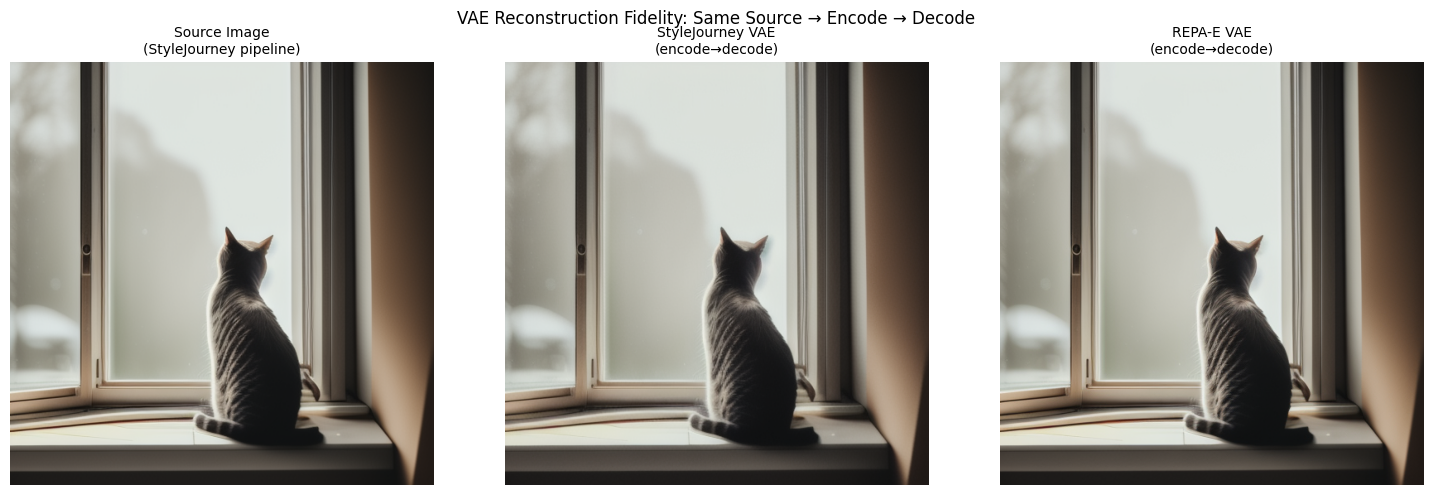

Reconstruction comparison saved


In [12]:
# @title 7.1 VAE reconstruction comparison (encode → decode round-trip)
# Encode the same source image with both VAEs, decode with each.
# Compare: original | SJ-VAE encode→decode | REPA-E encode→decode

# Use the first reference image as our test source
source_img = ref_images[0]
source_tensor = (torch.from_numpy(np.array(source_img)).float() / 255.0 * 2 - 1).permute(2, 0, 1)
source_tensor = source_tensor.unsqueeze(0).to(device, dtype=torch.float32)

# Encode + decode with StyleJourney VAE
with torch.no_grad():
    sj_enc = stylejourney_vae.encode(source_tensor).latent_dist.sample()
    sj_z = sj_enc * stylejourney_vae.config.scaling_factor
    sj_recon = decode_latents(sj_z, stylejourney_vae)
    print(f"StyleJourney VAE: latent shape {sj_enc.shape}, latent range [{sj_enc.min().item():.3f}, {sj_enc.max().item():.3f}]")

# Encode + decode with REPA-E VAE
with torch.no_grad():
    # REPA-E encode returns DiagonalGaussianDistribution with .sample()
    repa_enc = repa_vae.encode(source_tensor)
    repa_z = repa_enc.sample()
    print(f"REPA-E VAE: latent shape {repa_z.shape}, latent range [{repa_z.min().item():.3f}, {repa_z.max().item():.3f}]")
    # REPA-E decode needs un-normalized latents (no batch-norm). The VAE produces un-normalized.
    # We temporarily disable the denormalize wrapper to decode raw VAE latents.
    repa_recon = original_repa_decode(repa_z).sample
    repa_recon = (repa_recon / 2 + 0.5).clamp(0, 1)
    repa_recon = Image.fromarray((repa_recon[0].cpu().permute(1, 2, 0).float().numpy() * 255).astype(np.uint8))

# Show: original | StyleJourney reconstruction | REPA-E reconstruction
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(source_img)
axes[0].set_title("Source Image\n(StyleJourney pipeline)", fontsize=10)
axes[0].axis("off")
axes[1].imshow(sj_recon)
axes[1].set_title("StyleJourney VAE\n(encode→decode)", fontsize=10)
axes[1].axis("off")
axes[2].imshow(repa_recon)
axes[2].set_title("REPA-E VAE\n(encode→decode)", fontsize=10)
axes[2].axis("off")
plt.suptitle("VAE Reconstruction Fidelity: Same Source → Encode → Decode")
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/vae_reconstruction_comparison.png", dpi=100)
plt.show()
print("Reconstruction comparison saved")


## Section 7b: Cross-VAE Decode Experiment

The REPA-E paper describes the E2E-VAE as a "drop-in replacement" for SD-VAE.
But what does this actually mean?

Both VAEs have the same architecture (AutoencoderKL, ch_mult=[1,2,4,4], 4 latent
channels, 8x downsampling). The difference is in how latents interface with the
diffusion model:

- **SD-VAE**: latents are scaled by `0.18215` before entering the UNet
- **REPA-E VAE**: latents are normalized per-channel via batch-norm
  `z_norm = (z - bias) * scale` before entering the diffusion model

**Drop-in replacement means**: you can use the REPA-E VAE in _a new training run_
instead of SD-VAE, and the diffusion model will learn its latent distribution.
It does NOT mean swapping VAEs in an _already-trained_ pipeline will work —
the UNet was trained for SD-VAE's specific latent distribution.

That said, the latent spaces may be close enough for meaningful cross-decode.
This section tests: generate latents with SJ UNet (trained for SD-VAE latents),
decode with both VAEs. If REPA-E produces recognizable images, the latent
spaces overlap. If it produces noise, the distributions are too different.


In [13]:
# @title 7b.1 Cross-VAE decode: SJ UNet latents → both VAEs
# Generate latents with SJ UNet (trained for SD-VAE latent space),
# decode with both VAEs. This tests latent space compatibility.

cross_prompts = [
    "a cat sitting on a windowsill looking outside",
    "a watercolor painting of a mountain lake",
    "a neon-lit cyberpunk alleyway at night",
]

sj_decoded = []
repa_decoded = []
repa_decoded_no_denorm = []  # REPA-E decode without batch-norm denorm

for ptxt in cross_prompts:
    print(f"\nGenerating: {ptxt}")
    latents = generate_latents(ptxt, steps=VAL_STEPS, guidance=VAL_GUIDANCE,
                               seed=42, negative_prompt="")

    # StyleJourney VAE decode (native path)
    sj_img = decode_latents(latents, stylejourney_vae)
    sj_decoded.append(sj_img)

    # REPA-E VAE decode with batch-norm denormalization
    # SJ latents are in 0.18215-scaled space. REPA-E expects batch-norm space.
    # We undo SD scaling then apply REPA-E denorm: z / 0.18215 / scale + bias
    with torch.no_grad():
        z_raw = latents / stylejourney_vae.config.scaling_factor  # undo 0.18215
        z_repa = repa_vae.decode(z_raw).sample  # with denorm wrapper: z_raw / scale + bias
        repa_img = ((z_repa / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        repa_img = Image.fromarray(repa_img)
        repa_decoded.append(repa_img)

    # REPA-E VAE decode WITHOUT batch-norm denormalization
    with torch.no_grad():
        z_raw = latents / stylejourney_vae.config.scaling_factor
        z_repa_raw = original_repa_decode(z_raw).sample  # skip denorm wrapper
        repa_img_raw = ((z_repa_raw / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        repa_img_raw = Image.fromarray(repa_img_raw)
        repa_decoded_no_denorm.append(repa_img_raw)

# Show 3-row grid: SJ decode | REPA-E decode (with denorm) | REPA-E decode (raw)
fig, axes = plt.subplots(3, len(cross_prompts), figsize=(5 * len(cross_prompts), 15))
for col, (sj_img, repa_img, repa_raw, ptxt) in enumerate(zip(sj_decoded, repa_decoded, repa_decoded_no_denorm, cross_prompts)):
    axes[0, col].imshow(sj_img)
    axes[0, col].set_title(f"StyleJourney VAE\n{ptxt[:30]}...", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(repa_img)
    axes[1, col].set_title(f"REPA-E VAE (denorm)\n{ptxt[:30]}...", fontsize=9)
    axes[1, col].axis("off")
    axes[2, col].imshow(repa_raw)
    axes[2, col].set_title(f"REPA-E VAE (raw, no denorm)\n{ptxt[:30]}...", fontsize=9)
    axes[2, col].axis("off")
plt.suptitle("Cross-VAE Decode: SJ UNet latents → Two VAEs", fontsize=14)
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/cross_vae_decode_comparison.png", dpi=100)
plt.show()
print("Cross-VAE decode comparison saved")


Output hidden; open in https://colab.research.google.com to view.

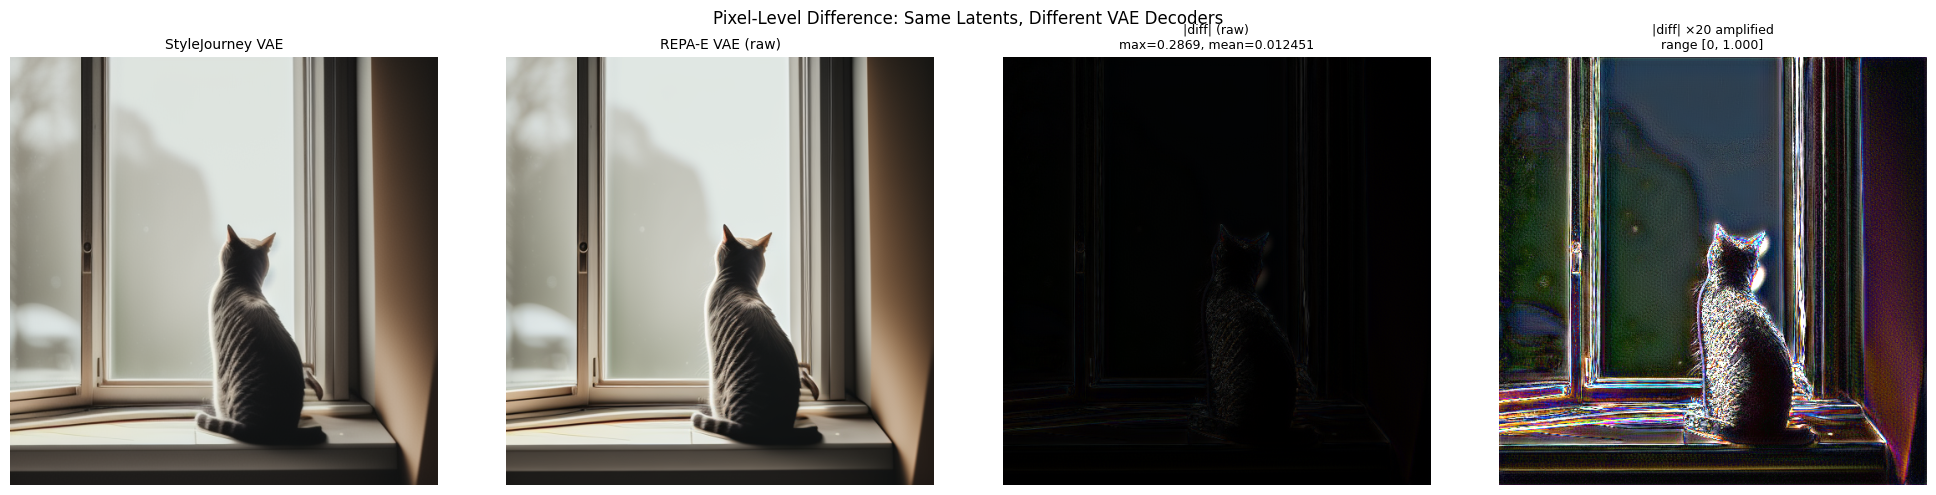

Pixel diff stats: max=0.286932, mean=0.01245084, std=0.01564023
  R channel: max=0.274265, mean=0.01259200, std=0.01596420
  G channel: max=0.286932, mean=0.01227947, std=0.01555486
  B channel: max=0.265451, mean=0.01248103, std=0.01539451


In [14]:
# @title 7b.2 Pixel-level difference: SJ VAE decode vs REPA-E VAE decode
# Same latents, different decoder — subtract to see per-pixel delta.

prompt = "a cat sitting on a windowsill looking outside"
latents = generate_latents(prompt, steps=30, guidance=5.0, seed=42, negative_prompt="")

# Decode with both VAEs (raw, no denorm)
with torch.no_grad():
    # StyleJourney VAE
    z_sj = latents / stylejourney_vae.config.scaling_factor
    sj_tensor = stylejourney_vae.decode(z_sj.to(dtype=vae_dtype_sj)).sample
    sj_np = (sj_tensor / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).float().numpy()

    # REPA-E VAE (raw, no denorm)
    z_repa = latents / stylejourney_vae.config.scaling_factor
    repa_tensor = original_repa_decode(z_repa.to(dtype=next(repa_vae.parameters()).dtype)).sample
    repa_np = (repa_tensor / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).float().numpy()

# Compute difference map
diff = np.abs(sj_np - repa_np)
diff_amplified = np.clip(diff * 20, 0, 1)  # amplify 20x for visibility

# Show 4-panel: SJ | REPA-E | raw diff | amplified diff
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(sj_np)
axes[0].set_title("StyleJourney VAE", fontsize=10)
axes[0].axis("off")
axes[1].imshow(repa_np)
axes[1].set_title("REPA-E VAE (raw)", fontsize=10)
axes[1].axis("off")
axes[2].imshow(diff, cmap="hot")
axes[2].set_title(f"|diff| (raw)\nmax={diff.max():.4f}, mean={diff.mean():.6f}", fontsize=9)
axes[2].axis("off")
axes[3].imshow(diff_amplified, cmap="hot")
axes[3].set_title(f"|diff| ×20 amplified\nrange [0, {diff_amplified.max():.3f}]", fontsize=9)
axes[3].axis("off")
plt.suptitle("Pixel-Level Difference: Same Latents, Different VAE Decoders")
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/vae_pixel_diff.png", dpi=150)
plt.show()
print(f"Pixel diff stats: max={diff.max():.6f}, mean={diff.mean():.8f}, std={diff.std():.8f}")

# Also compute per-channel stats
for c, name in enumerate(["R", "G", "B"]):
    ch_diff = diff[:, :, c]
    print(f"  {name} channel: max={ch_diff.max():.6f}, mean={ch_diff.mean():.8f}, std={ch_diff.std():.8f}")


## Section 8: Gradient Sky / Smooth Gradient Test

VAE artifacts are most visible in smooth gradients. Test with a synthetic linear
gradient to expose checkerboard/blocking artifacts from each VAE.


StyleJourney VAE gradient: latent std=5.8815
REPA-E VAE gradient: latent std=5.8692


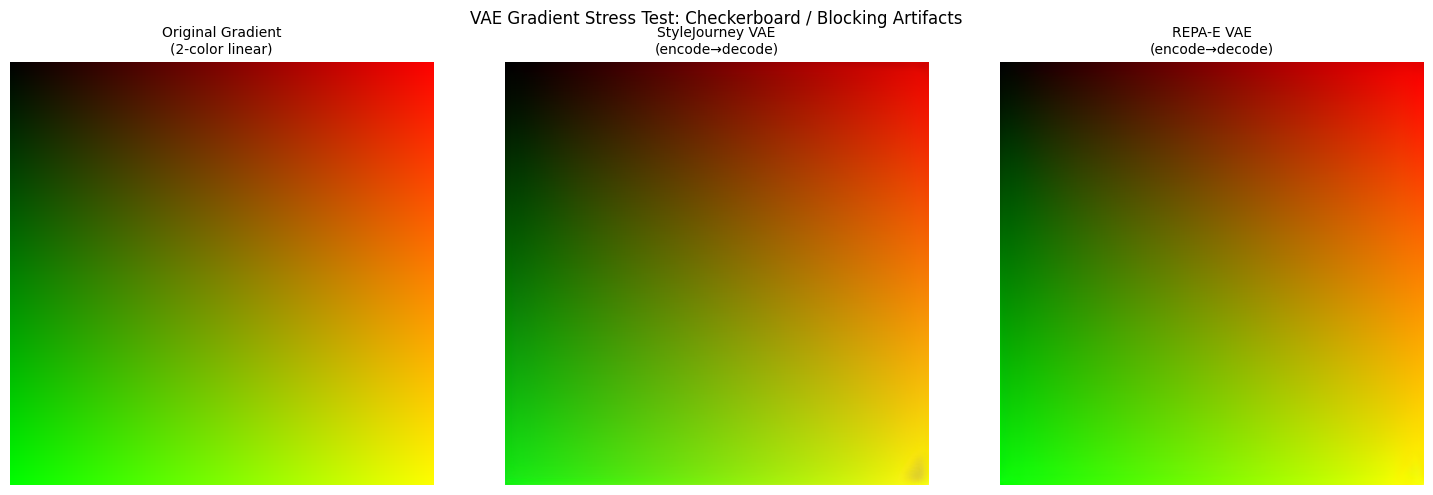

Gradient stress test saved


In [15]:
# @title 8.1 Synthetic gradient stress test (both VAEs)
# VAE artifacts are most visible in smooth gradients.
# Encode the same gradient with each VAE, decode with same VAE,
# to expose checkerboard/blocking artifacts per VAE.

# Create a smooth gradient image
h, w = 512, 512
y = torch.linspace(-1, 1, h).view(-1, 1).expand(h, w)
x = torch.linspace(-1, 1, w).view(1, -1).expand(h, w)
gradient_r = x * 0.5 + 0.5  # [h, w]
gradient_g = y * 0.5 + 0.5  # [h, w]
gradient_b = torch.zeros(h, w)  # [h, w]
gradient_img = torch.stack([gradient_r, gradient_g, gradient_b], dim=0)  # [3, H, W]
gradient_img = (gradient_img * 2 - 1).unsqueeze(0).to(device, dtype=torch.float32)

# Encode + decode with StyleJourney VAE
with torch.no_grad():
    sj_grad_z = stylejourney_vae.encode(gradient_img).latent_dist.sample()
    sj_grad_z_scaled = sj_grad_z * stylejourney_vae.config.scaling_factor
    grad_sj = decode_latents(sj_grad_z_scaled, stylejourney_vae)
    print(f"StyleJourney VAE gradient: latent std={sj_grad_z.std().item():.4f}")

# Encode + decode with REPA-E VAE
with torch.no_grad():
    repa_grad_z = repa_vae.encode(gradient_img).sample()
    grad_repa_raw = original_repa_decode(repa_grad_z).sample
    grad_repa = ((grad_repa_raw / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    grad_repa = Image.fromarray(grad_repa)
    print(f"REPA-E VAE gradient: latent std={repa_grad_z.std().item():.4f}")

# Show: original gradient | SJ VAE reconstruction | REPA-E VAE reconstruction
orig_np = (gradient_img[0].cpu() / 2 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_np)
axes[0].set_title("Original Gradient\n(2-color linear)", fontsize=10)
axes[0].axis("off")
axes[1].imshow(grad_sj)
axes[1].set_title("StyleJourney VAE\n(encode→decode)", fontsize=10)
axes[1].axis("off")
axes[2].imshow(grad_repa)
axes[2].set_title("REPA-E VAE\n(encode→decode)", fontsize=10)
axes[2].axis("off")
plt.suptitle("VAE Gradient Stress Test: Checkerboard / Blocking Artifacts")
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/vae_gradient_stress_test.png", dpi=100)
plt.show()
print("Gradient stress test saved")


---

## Results

All comparison grids saved to Google Drive:
- `reference_images_stylejourney.png` — reference images from full SJ pipeline
- `ref_*.png` — individual reference images
- `vae_reconstruction_comparison.png` — encode→decode fidelity (same source, both VAEs)
- `cross_vae_decode_comparison.png` — SJ UNet latents decoded with both VAEs
- `vae_gradient_stress_test.png` — synthetic gradient artifact test

## What to look for

1. **Reconstruction (Section 7)**: how well each VAE preserves details when
   encoding and decoding the same image. Lower error = better fidelity.
2. **Cross-decode (Section 7b)**: can REPA-E VAE decode SD-UNet latents
   meaningfully? If the latent spaces are incompatible, REPA-E output will be
   noise/washed out. If they overlap, you'll see the same image with different
   texture/artifact characteristics.
3. **Gradient test (Section 8)**: checkerboard artifacts and blocking will be
   visible as grid patterns in the smooth gradient reconstruction.

## Notes

- Both VAEs share the same **architecture** (AutoencoderKL, ch_mult=[1,2,4,4],
  embed_dim=4). They differ in **weights** and **latent normalization**.
- REPA-E VAE uses per-channel batch-norm latent stats for the diffusion model
  interface; SD-VAE uses the scalar 0.18215 scaling factor.
- "Drop-in replacement" means you can use REPA-E VAE when training a new model
  from scratch. It doesn't guarantee cross-compatibility with an already-trained
  UNet's latent space.
- The cross-decode experiment lets you judge empirically how close the two latent
  spaces are.


In [16]:
from google.colab import runtime
runtime.unassign()